In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style='whitegrid')

df = sns.load_dataset('titanic')


url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print(df.shape)
print(df.dtypes)
print(df.head(3))

(891, 12)
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  


In [3]:
print(df.isnull().sum())

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna('S')
df = df.drop(columns=['Cabin'])

df['Survived'] = df['Survived'].astype('int')
df['Pclass']   = df['Pclass'].astype('str')
df['Sex']      = df['Sex'].astype('category')

print('Missing after cleaning:', df.isnull().sum().sum())
print(df.describe())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Missing after cleaning: 0
       PassengerId    Survived         Age       SibSp       Parch        Fare
count   891.000000  891.000000  891.000000  891.000000  891.000000  891.000000
mean    446.000000    0.383838   29.361582    0.523008    0.381594   32.204208
std     257.353842    0.486592   13.019697    1.102743    0.806057   49.693429
min       1.000000    0.000000    0.420000    0.000000    0.000000    0.000000
25%     223.500000    0.000000   22.000000    0.000000    0.000000    7.910400
50%     446.000000    0.000000   28.000000    0.000000    0.000000   14.454200
75%     668.500000    1.000000   35.000000    1.000000    0.000000   31.000000
max     891.000000    1.000000   80.000000    8.000000    6.000000  512.329200


In [4]:
survival_rate = df['Survived'].mean() * 100
print(f'Overall survival rate: {survival_rate:.1f}%')

sex_survival = df.groupby('Sex', observed=False)['Survived'].mean() * 100
print(sex_survival)

class_survival = df.groupby('Pclass', observed=False)['Survived'].mean() * 100
print(class_survival.sort_values(ascending=False))

avg_fare = df.groupby('Pclass', observed=False)['Fare'].mean().round(2)
print(avg_fare)

port_counts = df.groupby('Embarked', observed=False)['Embarked'].count()
print(port_counts)


Overall survival rate: 38.4%
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64
Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64
Embarked
C    168
Q     77
S    646
Name: Embarked, dtype: int64


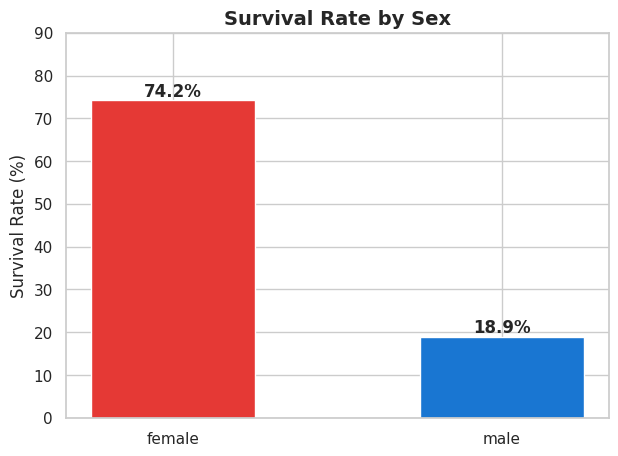

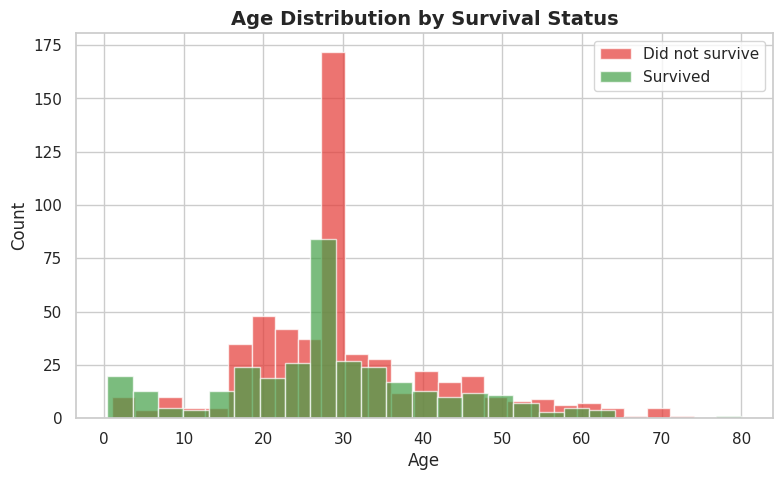

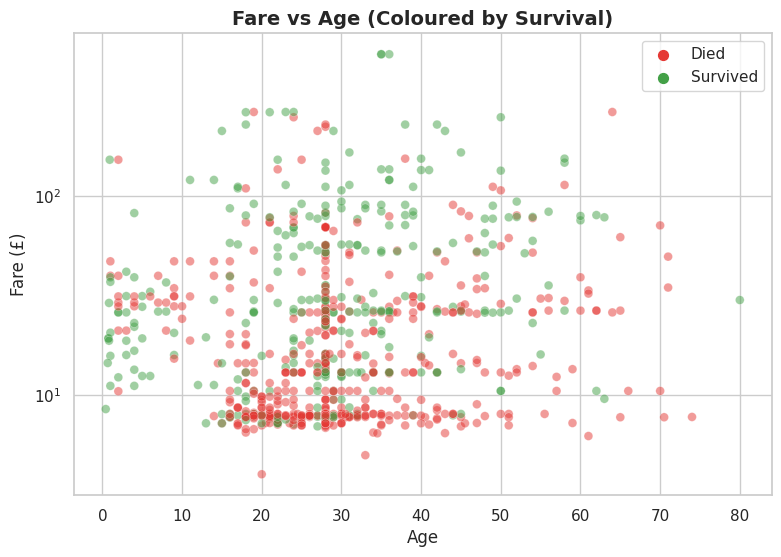

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
sex_data = df.groupby('Sex', observed=False)['Survived'].mean() * 100

bars = ax.bar(sex_data.index, sex_data.values,
              color=['#E53935', '#1976D2'], width=0.5, edgecolor='white')
for bar, val in zip(bars, sex_data.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+1,
           f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Survival Rate by Sex', fontsize=14, fontweight='bold')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 90)
plt.savefig('chart1_sex_survival.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df[df['Survived']==0]['Age'], bins=25, alpha=0.7,
        color='#E53935', label='Did not survive')
ax.hist(df[df['Survived']==1]['Age'], bins=25, alpha=0.7,
        color='#43A047', label='Survived')
ax.set_title('Age Distribution by Survival Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Age'); ax.set_ylabel('Count')
ax.legend()
plt.savefig('chart2_age_hist.png', dpi=150, bbox_inches='tight')
plt.show()

survived_map = {0: '#E53935', 1: '#43A047'}
colors = df['Survived'].map(survived_map)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df['Age'], df['Fare'], c=colors, alpha=0.5, s=40, edgecolors='white', lw=0.3)
for val, col, label in zip([0,1], ['#E53935','#43A047'], ['Died','Survived']):
    ax.scatter([], [], c=col, label=label, s=50)
ax.set_title('Fare vs Age (Coloured by Survival)', fontsize=14, fontweight='bold')
ax.set_xlabel('Age'); ax.set_ylabel('Fare (£)')
ax.legend(); ax.set_yscale('log')
plt.savefig('chart3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()